In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

In [87]:
df = pd.read_csv('titanic_dataset.csv', usecols=['Age','Fare','Survived'])

In [88]:
df.sample(5)

,Survived,Age,Fare
96,1,76.0,78.8500
295,0,26.0,7.8958
9,0,21.0,24.1500
50,0,24.0,60.0000
98,1,20.0,7.8542


In [89]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [90]:
# deleting all the rows if it contains null value either in fare or age
df.dropna(inplace = True)

In [91]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [92]:
df.shape

(331, 3)

#### Without using Binning

In [93]:
X = df.iloc[:,-2:]
X.sample(5)

,Age,Fare
135,24.0,7.8542
414,39.0,108.9000
383,19.0,16.1000
236,64.0,75.2500
360,14.5,69.5500


In [94]:
y=df.iloc[:,:1]
y.sample(5)

,Survived
30,0
349,1
368,1
272,1
386,0


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [96]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred1 = clf.predict(X_test)
accuracy_score(y_pred1,y_test)

0.582089552238806

In [97]:
np.mean(cross_val_score(clf,X,y, scoring='accuracy',cv=10))

np.float64(0.5620320855614972)

In [98]:
kbin_age = KBinsDiscretizer(n_bins=15, strategy='quantile',encode='ordinal')
kbin_fare= KBinsDiscretizer(n_bins=15,strategy='quantile',encode='ordinal')

In [99]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second', kbin_fare, [1])
])
#remainder -> automatically drop

In [100]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [101]:
trf.named_transformers_['first'].n_bins_

array([15])

In [102]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.        ,   7.42554   ,   7.77805333,   7.8958    ,
                8.6625    ,  12.25276667,  13.        ,  14.89108667,
               21.        ,  26.        ,  27.7208    ,  39.        ,
               58.41      ,  78.67944667, 141.32528   , 512.3292    ])],
      dtype=object)

In [103]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
})

output.sample(5)

,age,age_trf,fare,fare_trf
134,43.0,11.0,7.8958,3.0
48,60.0,14.0,76.2917,12.0
287,24.0,5.0,82.2667,13.0
190,34.0,9.0,26.0000,9.0
283,9.0,0.0,15.2458,7.0


In [104]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2= clf.predict(X_test_trf)

In [105]:
accuracy_score(y_test, y_pred2)

0.5970149253731343

In [106]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y, cv=10, scoring='accuracy'))

np.float64(0.5499108734402853)

In [107]:
def binning(nbins,strategy):
    kbins_age = KBinsDiscretizer(n_bins= nbins, strategy= strategy, encode='ordinal',quantile_method='averaged_inverted_cdf')
    kbins_fare= KBinsDiscretizer(n_bins=nbins, strategy = strategy, encode= 'ordinal', quantile_method='averaged_inverted_cdf')

    trf = ColumnTransformer([
        ('first',kbins_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_train_trf = trf.fit_transform(X_train)
    X_test_trf= trf.transform(X_test)

    clf= DecisionTreeClassifier()
    clf.fit(X_train_trf,y_train)
    ypred3= clf.predict(X_test_trf)
    print(accuracy_score(ypred3, y_test))

    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(X_train)
    plt.title("Before Transformation")

    plt.subplot(1,2,2)
    sns.histplot(X_train_trf)
    plt.title("After Transformation")

    plt.show()

0.5970149253731343


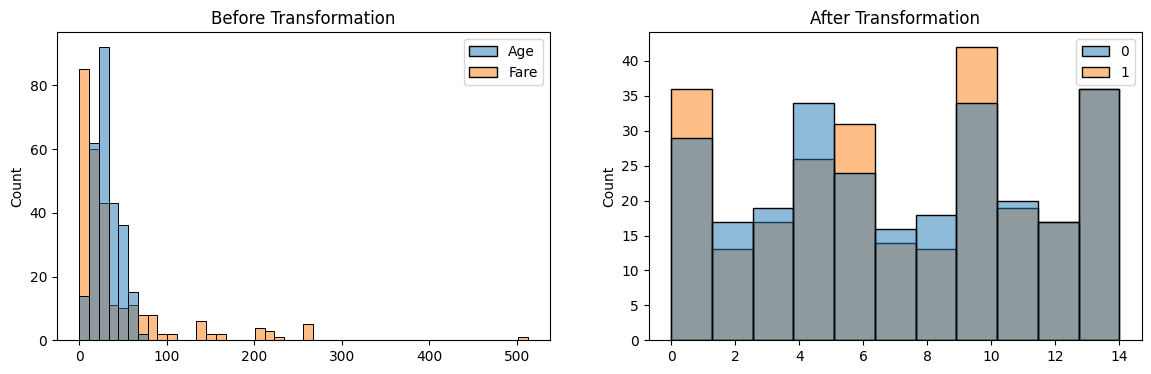

In [108]:
binning(15, 'quantile')

#### Custom / Domain Based Binning

In [109]:
#we can create the boundary of the bins by ourselves.
#we cannot make by using sklearn, we have to make this through Pandas